For Google Colab integration

In [3]:
!pip install -U ipython

!git clone https://github.com/AdrianPanasiewicz/QML_for_radar_classification.git
import sys
sys.path.append('/content/your-repo')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 625.7/625.7 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 61.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.4/85.4 kB 11.7 MB/s eta 0:00:00
  Attempting uninstall: traitlets
    Found existing installation: traitlets 5.7.1
    Uninstalling traitlets-5.7.1:
      Successfully uninstalled traitlets-5.7.1
  Attempting uninstall: decorator
    Found existing installation: decorator 4.4.2
    Uninstalling decorator-4.4.2:
      Successfully uninstalled decorator-4.4.2
  Attempting uninstall: ipython
    Found existing installation: ipython 7.34.0
    Uninstalling ipython-7.34.0:
      Successfully uninstalled ipython-7.34.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires ipython==7.34.0, but you have ipython 9.12.0 which is incompatible.
movie

In [5]:
%load_ext autoreload
%autoreload 2

%aimport -torch
%aimport -numpy
%aimport -qiskit
%aimport -pennylane
%aimport -ray
%aimport -sklearn

from pathlib import Path
import tempfile
import os
from functools import partial

# These import from Data folder are necessary for pickle load to work
from Data.Primitives.environment_classes import Drone, Radar, Context
from Data.Primitives.noise_models import AdditiveWhiteGaussianNoise
from Data.Primitives.presets import *
from Data.Generators.synthetic_dataset_generator import DatasetMetadata, DataRequest

from MachineLearning.Processing.file_loader import SyntheticDataFileLoader
from MachineLearning.Processing.frequency_domain_parser import FrequencyDomainDataParser
from MachineLearning.Processing.time_domain_parser import TimeDomainDataParser
from MachineLearning.Torch_datasets.synthetic_time_dataset import SyntheticTimeDomainRadarDataset
from MachineLearning.Torch_datasets.synthetic_frequency_dataset import SyntheticFrequencyDomainRadarDataset
from MachineLearning.Models.experiment_pure.classical_neural_network import ClassicalNeuralNetwork
from MachineLearning.Models.experiment_pure.quantum_neural_network import QuantumNeuralNetwork
from MachineLearning.Processing.data_visualizer import DataVisualizer
from MachineLearning.Trainers.statistical_trainer import TrainerForModelStatistics
from MachineLearning.Trainers.hyperparameter_trainer import TrainerForHyperparameterSearch

from matplotlib import pyplot as plt
import numpy as np

from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import sympy

import torch
from torch import nn
from torch.nn.functional import normalize
from torch.utils.data import DataLoader
from torch.optim import SGD

import ray
from ray import tune
from ray.tune import Checkpoint
from ray.tune.schedulers import ASHAScheduler

MODEL_REGISTRY = {
    "ClassicalNeuralNetwork": ClassicalNeuralNetwork,
}

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


ModuleNotFoundError: No module named 'Data'

In [3]:
# Run this in terminal before running this code block
# ray start --head --metrics-export-port=8080

PROJECT_ROOT = Path().cwd().parent
ray.shutdown()
ctx = ray.init(runtime_env={
    "working_dir": str(PROJECT_ROOT),
    "excludes": [
        "Data/Datasets"
    ]
})
print(ctx.dashboard_url)

2026-04-11 20:51:59,514	INFO worker.py:1837 -- Connecting to existing Ray cluster at address: 127.0.0.1:6379...
2026-04-11 20:51:59,561	INFO worker.py:2014 -- Connected to Ray cluster. View the dashboard at http://127.0.0.1:8265 
2026-04-11 20:52:02,492	INFO packaging.py:588 -- Creating a file package for local module 'E:\Zycie\Nauka\Studia\Inf\Praca dyplomowa\Thesis_project\QML_for_radar_classification'.
2026-04-11 20:52:02,767	INFO packaging.py:380 -- Pushing file package 'gcs://_ray_pkg_d5a9461624d9169e.zip' (11.94MiB) to Ray cluster...
2026-04-11 20:52:02,811	INFO packaging.py:393 -- Successfully pushed file package 'gcs://_ray_pkg_d5a9461624d9169e.zip'.


127.0.0.1:8265


C:\Users\adria\miniconda3\envs\Qiskit_workshop\Lib\site-packages\ray\_private\worker.py:2062: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(
(raylet) E0411 20:55:24.788000000 21572 external/com_github_grpc_grpc/src/core/lib/iomgr/tcp_server_windows.cc:360] on_accept error: The I/O operation has been aborted because of either a thread exit or an application request.
(raylet) 
(raylet) E0411 21:14:59.152000000 14204 external/com_github_grpc_grpc/src/core/lib/iomgr/tcp_server_windows.cc:360] on_accept error: The I/O operation has been aborted because of either a thread exit or an application request.
(raylet) 


### Checking preprocessing functionalities

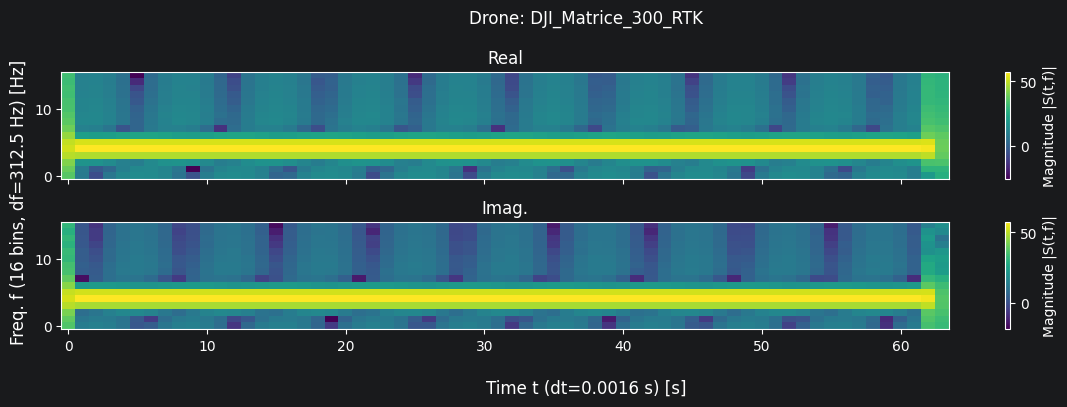

In [9]:
PROJECT_ROOT = Path().cwd().parent
type = "time_domain"
load_path = PROJECT_ROOT / "Data" / "Datasets" / type / "training_dataset.pkl"

md = DatasetMetadata.create_from_path(load_path)
synt_dataset = SyntheticDataFileLoader(dataset_metadata=md)

obj = synt_dataset.peek_sample(index=6000)

td_data_parser = TimeDomainDataParser()
signal, label, misc_data = td_data_parser.extract_training_data_and_label(obj)
td_data_parser.plot_drone_spectrogram(signal, misc_data, nperseg=32, noverlap=16)

In [10]:
parsed_signal, label, misc_data = td_data_parser.parse_data_object(obj)
parsed_signal, label, misc_data

(tensor([ 7.0232,  3.6288,  2.5064,  2.2650,  1.9713,  2.2520,  2.4046,  3.3200,
          6.2894, 89.2546]),
 1,
 DataRequest(request_name='label=DJI_Matrice_300_RTK', drone=Drone(name='DJI_Matrice_300_RTK', N=2, L_1=0.05, L_2=0.2665, f_rot=70), radar=Radar(λ=0.02998, f_c=9999748432.288193), context=Context(R=1520.0568606927932, V_rad=29.999718426099054, θ=0.3926806281264518, Φ_p=0.6228512920884408, A_r=7.299403777764336, snr=np.int64(25), t_start=0, t_stop=0.1, dt=0.0001), noise_model=<Data.noise_models.AdditiveWhiteGaussianNoise object at 0x000001B200591040>, sample_size=70))

In [11]:
PROJECT_ROOT = Path().cwd().parent
type = "frequency_domain"
load_path = PROJECT_ROOT / "Data" / "Datasets" / type / "training_dataset.pkl"

md = DatasetMetadata.create_from_path(load_path)
synt_dataset = SyntheticDataFileLoader(dataset_metadata=md)

obj = synt_dataset.peek_sample(index=6000)

td_data_parser = FrequencyDomainDataParser()
signal, label, misc_data = td_data_parser.parse_data_object(obj, bin_size=1, return_mag=False)
print(signal.shape)

torch.Size([2, 16, 64])


### Statistical learner

In [9]:
def l1_normalize_1d(x):
    return normalize(x, p=1, dim=0)

def l2_normalize_1d(x):
    return normalize(x, dim=0)

In [ ]:
PROJECT_ROOT = Path().cwd().parent
training_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "training_dataset.pkl"
validating_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "validating_dataset.pkl"
testing_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "testing_dataset.pkl"


config = {
    "layers": 2,
    "neurons_per_layer": 1000,
    "lr": 1e-3,
    "batch_size": 16,
    "device": "gpu",
    'epochs' : 100
}

trainer = TrainerForModelStatistics(training_path, validating_path, testing_path, criterion = nn.CrossEntropyLoss())
data_array_all_runs = trainer.train_model(ClassicalNeuralNetwork, config, number_of_trials=10, number_of_epochs=500)

Model runs:  70%|███████   | 7/10 [17:58<07:44, 154.70s/it]

In [ ]:
data_array = torch.tensor(
    [data_array_all_runs[i]['accuracy'] for i in range(len(data_array_all_runs))],
    dtype=torch.float32
)

plotter = DataVisualizer()
means, stds = plotter.calculate_statistics(data_array)
plotter.plot_statistics(means, stds)

### Hyperparameter learner

In [ ]:
config_params = 32
divs_array = sympy.divisors(config_params)

pair_map = {div : config_params // div for div in divs_array}

config = {
    "layers": tune.grid_search(list(pair_map.keys())),
    "neurons_per_layer": tune.sample_from(lambda config: pair_map[config["layers"]]),
    "lr": tune.loguniform(1e-4, 1e-1),
    "batch_size": tune.choice([2, 4, 8, 16]),
    "device": "cpu",
    'epochs' : 100
}

max_num_epochs = 100
num_trials =  100
scheduler = ASHAScheduler(
    max_t=max_num_epochs,
    grace_period=1,
    reduction_factor=2,
)

cpus_per_trial = 4
gpus_per_trial = 0

PROJECT_ROOT = Path().cwd().parent
training_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "training_dataset.pkl"
validating_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "validating_dataset.pkl"
testing_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "testing_dataset.pkl"

trainer = TrainerForHyperparameterSearch(
    training_path=training_path,
    validating_path=validating_path,
    testing_path=testing_path,
    criterion = nn.CrossEntropyLoss()
)

tuner = tune.Tuner(
    tune.with_resources(
        tune.with_parameters(trainer.train_model, model_class=ClassicalNeuralNetwork),
        resources={"cpu": cpus_per_trial, "gpu": gpus_per_trial}
    ),
    tune_config=tune.TuneConfig(
        metric="loss",
        mode="min",
        scheduler=scheduler,
        num_samples=num_trials,
        trial_dirname_creator=lambda trial: f"t_{trial.trial_id}"
    ),
    param_space=config,
)
results = tuner.fit()

### Quantum Neural Network

In [13]:
batch_size = 64
num_qubits = 10

PROJECT_ROOT = Path().cwd().parent
training_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "training_dataset.pkl"
validating_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "validating_dataset.pkl"

training_data = SyntheticTimeDomainRadarDataset(training_path)
validating_data = SyntheticTimeDomainRadarDataset(validating_path, mean=training_data.mean, std=training_data.std)

train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
validating_dataloader = DataLoader(validating_data, batch_size=64, shuffle=True)

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
quantum_model = QuantumNeuralNetwork(num_qubits).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(quantum_model.parameters(), lr=1e-3)

trainer = TrainerForHyperparameterSearch(
    training_dataloader=train_dataloader,
    validating_dataloader=validating_dataloader,
    testing_dataloader=None,
    loss_fn=criterion,
)

epochs = 10
accuracy_array=[]
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    trainer.train()
    acc = trainer.test()
    accuracy_array.append(acc)
print("Done!")

Epoch 1
-------------------------------
loss: 1.802852  [   64/ 4620]
Test Error: 
 Accuracy: 15.5%, Avg loss: 1.795701 

Epoch 2
-------------------------------
loss: 1.784019  [   64/ 4620]
Test Error: 
 Accuracy: 15.5%, Avg loss: 1.795918 

Epoch 3
-------------------------------
loss: 1.789067  [   64/ 4620]
Test Error: 
 Accuracy: 15.5%, Avg loss: 1.795346 

Epoch 4
-------------------------------
loss: 1.792531  [   64/ 4620]
Test Error: 
 Accuracy: 15.5%, Avg loss: 1.795292 

Epoch 5
-------------------------------
loss: 1.789393  [   64/ 4620]


KeyboardInterrupt: 